In [2]:
import ee
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import hydropandas as hpd
from tsconfig import extent_to_rd, extent_to_ee, NDVI_START_DATE, NDVI_END_DATE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.tsa.ardl import ARDL
from IPython.display import display, Markdown

In [3]:
organisation = "rotterdam"
auth = ("__key__", "D5aclEis.RBUeIvKA6jrLVUzNpPATjvGyLXsLAx7P")

In [4]:
my_extent = extent_to_rd("gw") 
oc = hpd.read_lizard(
    extent=my_extent,
    which_timeseries=["hand", "diver", "diver_validated"],
    datafilters=None,
    combine_method="merge",
    organisation=organisation,
    auth=auth,
)

monitoring well: 100%|██████████| 2/2 [00:07<00:00,  3.61s/it]


In [5]:
project = 'afstuderen-481613'

try:
    ee.Initialize(project=project)
except:
    ee.Authenticate()
    ee.Initialize(project=project)

roi = ee.Geometry.Rectangle(extent_to_ee("ndvi"))

In [6]:
# Retrieve KNMI meteorological data
gw = oc.obs["GMW000000046935001"]

# Filter on date range (use NDVI date range for consistency)
tmin = datetime.datetime.strptime(NDVI_START_DATE, "%Y-%m-%d").date()
tmax = datetime.datetime.strptime(NDVI_END_DATE, "%Y-%m-%d").date()

precipitation = hpd.PrecipitationObs.from_knmi(
    xy=(gw.x, gw.y),
    start=tmin,
    end=tmax,
    fill_missing_obs=True,
)
evaporation = hpd.EvaporationObs.from_knmi(
    xy=(gw.x, gw.y),
    meteo_var="EV24",
    start=tmin,
    end=tmax,
    fill_missing_obs=True,
)

print("Meteorological data retrieved from KNMI")
print(f"Precipitation: {len(precipitation)} records")
print(f"Evaporation: {len(evaporation)} records")

Meteorological data retrieved from KNMI
Precipitation: 1736 records
Evaporation: 1736 records


c:\Users\odin0\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


<Axes: title={'center': 'meteo observations'}, ylabel='m/dag'>

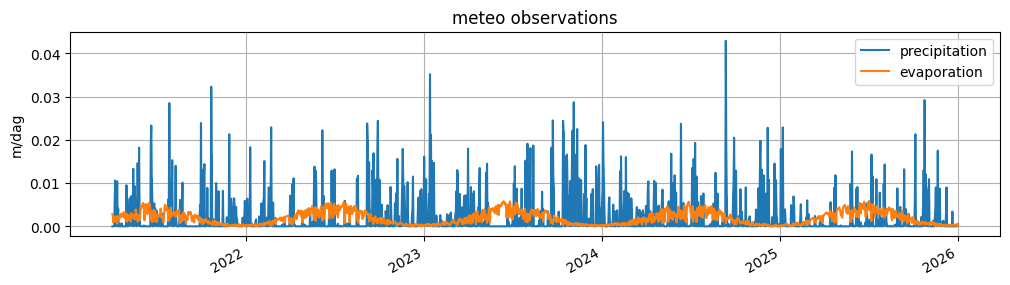

In [7]:
# --- Plot as spikes (like rainfall graphs) ---
fig, ax = plt.subplots(figsize=(12, 3))

# precipitation as vertical lines
ax.vlines(
    precipitation.index,
    ymin=0,
    ymax=precipitation["RH"],
    linewidth=0.6,
    label="precipitation",
)

ax = precipitation["RH"].plot(label="precipitation", legend=True, figsize=(12, 3))
evaporation["EV24"].plot(
    ax=ax,
    label="evaporation",
    legend=True,
    grid=True,
    ylabel="m/dag",
    title="meteo observations",
)

In [8]:
# ---------- helpers ----------
def ee_fc_to_df(fc, props=("date", "ndvi", "n_pixels")):
    feats = fc.getInfo()["features"]
    rows = []
    for f in feats:
        p = f.get("properties", {})
        if all(p.get(k) is not None for k in props):
            rows.append({k: p.get(k) for k in props})
    df = pd.DataFrame(rows)
    if not df.empty:
        df["date"] = pd.to_datetime(df["date"])
        df["ndvi"] = df["ndvi"].astype(float)
        df["n_pixels"] = df["n_pixels"].astype(float)
        df = df.sort_values("date").reset_index(drop=True)
    return df


def reduce_ndvi_mean_and_count(img, roi, scale):
    stats = img.select("NDVI").reduceRegion(
        reducer=ee.Reducer.mean().combine(ee.Reducer.count(), None, True),
        geometry=roi,
        scale=scale,
        bestEffort=True,
        maxPixels=1e13,
    )
    date = ee.Date(img.get("system:time_start")).format("YYYY-MM-dd")
    return ee.Feature(None, {
        "date": date,
        "ndvi": stats.get("NDVI_mean"),
        "n_pixels": stats.get("NDVI_count"),
    })


def ndvi_timeseries(collection_id, roi, start_date, end_date, scale,
                    add_ndvi_fn, mask_fn=None, extra_filter=None):

    col = (ee.ImageCollection(collection_id)
           .filterBounds(roi)
           .filterDate(start_date, end_date))

    if extra_filter is not None:
        col = col.filter(extra_filter)
    if mask_fn is not None:
        col = col.map(mask_fn)

    col = col.map(add_ndvi_fn)

    fc = col.map(lambda img: reduce_ndvi_mean_and_count(img, roi, scale))
    df = ee_fc_to_df(ee.FeatureCollection(fc))
    return df


# ---------- Sentinel-2 specifics ----------
def mask_s2_clouds(img):
    scl = img.select("SCL")
    mask = (scl.neq(3)
            .And(scl.neq(7))
            .And(scl.neq(8))
            .And(scl.neq(9))
            .And(scl.neq(10))
            .And(scl.neq(11)))
    return img.updateMask(mask)


def add_ndvi_s2(img):
    return img.addBands(img.normalizedDifference(["B8", "B4"]).rename("NDVI"))


# ---------- Run Sentinel‑2 only ----------
df_s2 = ndvi_timeseries(
    collection_id="COPERNICUS/S2_SR_HARMONIZED",
    roi=roi,
    start_date=NDVI_START_DATE,
    end_date=NDVI_END_DATE,
    scale=10,
    add_ndvi_fn=add_ndvi_s2,
    mask_fn=mask_s2_clouds,
    extra_filter=ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30),
)

df_s2

,date,ndvi,n_pixels
0,2021-04-20,0.393626,95572.0
1,2021-04-20,0.385984,95710.0
2,2021-05-30,0.534670,119336.0
3,2021-05-30,0.525492,119462.0
4,2021-06-09,0.513945,89658.0
...,...,...,...
130,2025-09-01,0.533492,100610.0
131,2025-12-25,0.406802,137593.0
132,2025-12-25,0.423210,138095.0
133,2025-12-30,0.449057,138195.0


,count
status,
kept,97
removed,38


,date,ndvi,n_pixels
0,2021-04-20,0.393626,95572.0
1,2021-04-20,0.385984,95710.0
2,2021-06-09,0.513945,89658.0
3,2021-08-03,0.243233,1201.0
4,2021-09-07,0.531032,78746.0
5,2021-11-21,0.545338,64973.0
6,2021-12-16,0.469560,90688.0
7,2021-12-16,0.563803,93576.0
8,2022-02-14,0.445957,13984.0
9,2022-03-06,0.424603,90170.0


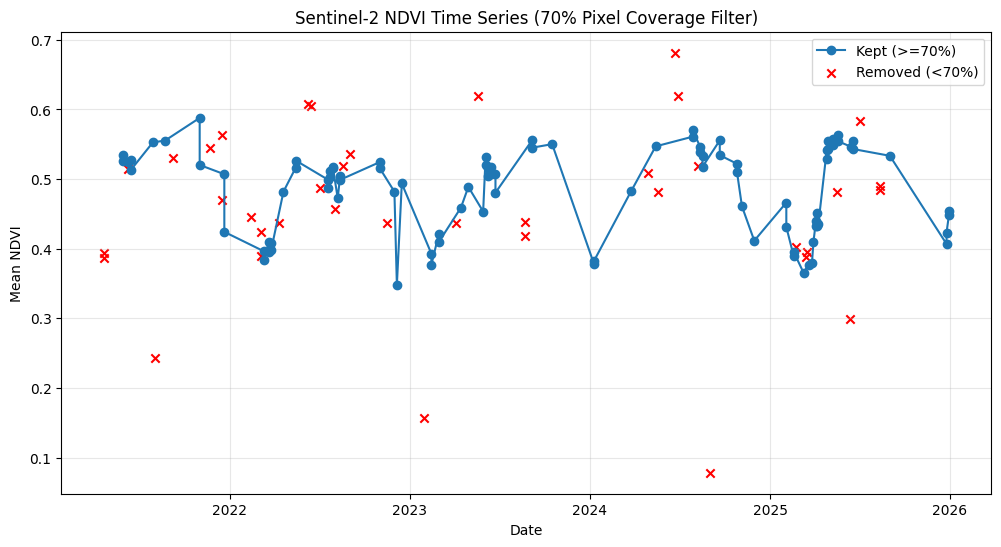

In [9]:
# Compute expected number of 10m pixels in ROI
roi_area_m2 = roi.area().getInfo()
pixel_area = 10 * 10
expected_pixels = roi_area_m2 / pixel_area

# 70% threshold
threshold = expected_pixels * 0.70

# Apply threshold
df = df_s2.copy()
df["min_required"] = threshold
df["status"] = np.where(df["n_pixels"] >= df["min_required"], "kept", "removed")

df_kept = df[df["status"] == "kept"].reset_index(drop=True)
df_removed = df[df["status"] == "removed"].reset_index(drop=True)

# Summary
summary = df.groupby("status").size().to_frame("count")
display(summary)

# Show removed rows
display(df_removed[["date", "ndvi", "n_pixels"]])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df_kept["date"], df_kept["ndvi"], marker="o", label="Kept (>=70%)")

if len(df_removed) > 0:
    plt.scatter(df_removed["date"], df_removed["ndvi"], marker="x", color="red", label="Removed (<70%)")

plt.legend()
plt.xlabel("Date")
plt.ylabel("Mean NDVI")
plt.title("Sentinel‑2 NDVI Time Series (70% Pixel Coverage Filter)")
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# ================================
# Monthly aggregation (after pixel coverage filter)
# ================================

# NDVI: use only the kept pixels (>=70% coverage) and filter by date range,
# then aggregate to monthly mean
df_s2_filtered = df_kept[
    (df_kept["date"] >= NDVI_START_DATE) & 
    (df_kept["date"] <= NDVI_END_DATE)
].copy()

df_s2_copy = df_s2_filtered.copy()
df_s2_copy["year_month"] = df_s2_copy["date"].dt.to_period("M")
df_s2_month = df_s2_copy.groupby("year_month").agg({
    "ndvi": "mean",
    "date": "first"
}).reset_index(drop=True)
df_s2_month = df_s2_month.rename(columns={"ndvi": "ndvi_month"})
print(f"NDVI data filtered (after pixel coverage): {len(df_kept)} -> {len(df_s2_filtered)} records ({len(df_s2_month)} months)")
print(f"NDVI data filtered: {len(df_s2)} -> {len(df_s2_filtered)} records ({len(df_s2_month)} months)")

# Meteorological data: aggregate to monthly mean
# Daily recharge = precipitation - evaporation
P_daily = precipitation["RH"].resample("D").sum()
E_daily = evaporation["EV24"].resample("D").sum()
recharge_daily = P_daily - E_daily  # already in mm

# Monthly aggregation
meteo_df = pd.DataFrame({
    'date': P_daily.index,
    'P': P_daily.values,
    'E': E_daily.values,
    'recharge': recharge_daily.values
})
meteo_df['year_month'] = pd.to_datetime(meteo_df['date']).dt.to_period('M')

meteo_month = meteo_df.groupby('year_month').agg({
    'P': 'sum',
    'E': 'sum',
    'recharge': 'sum',
    'date': 'first'
}).reset_index(drop=True)
meteo_month = meteo_month.rename(columns={'recharge': 'recharge_month', 'P': 'P_month', 'E': 'E_month'})

print(f"Meteo data aggregated to {len(meteo_month)} months")

display(df_s2_month.head())
display(meteo_month.head())

NDVI data filtered (after pixel coverage): 97 -> 97 records (35 months)
NDVI data filtered: 135 -> 97 records (35 months)
Meteo data aggregated to 57 months


,ndvi_month,date
0,0.530081,2021-05-30
1,0.521325,2021-06-09
2,0.552712,2021-07-29
3,0.555448,2021-08-23
4,0.554126,2021-11-01


,P_month,E_month,recharge_month,date
0,0.0500,0.0638,-0.0138,2021-04-01
1,0.1192,0.0737,0.0455,2021-05-01
2,0.0724,0.1094,-0.0370,2021-06-01
3,0.0744,0.0871,-0.0127,2021-07-01
4,0.0728,0.0790,-0.0062,2021-08-01


In [11]:
# --- Groundwater: maandgemiddelde per maand ---
gw_filtered = gw[(gw.index >= NDVI_START_DATE) & (gw.index <= NDVI_END_DATE)].copy()
gw_month_df = gw_filtered.reset_index()
gw_month_df.columns = ["peil_datum_tijd", "peil_waarde_cm", "flag", "comment", "origin"]
gw_month_df["peil_datum_tijd"] = pd.to_datetime(gw_month_df["peil_datum_tijd"])
gw_month_df["year_month"] = gw_month_df["peil_datum_tijd"].dt.to_period("M")
gw_month = gw_month_df.groupby("year_month").agg({
    "peil_waarde_cm": "mean",
    "peil_datum_tijd": "first"
}).reset_index(drop=True)
gw_month = gw_month.rename(columns={"peil_waarde_cm": "gw_month"})
gw_month["date"] = pd.to_datetime(gw_month["peil_datum_tijd"])


In [12]:
# =============================================================================
# CLEAN & ROBUST MERGE + INTERPOLATION – datetime-safe version
# =============================================================================

import pandas as pd

# ────────────────────────────────────────────────
# 1. Standardize ALL input dataframes to have real datetime 'date'
# ────────────────────────────────────────────────
for name, df in [
    ("NDVI (df_s2_month)", df_s2_month),
    ("Meteo (meteo_month)", meteo_month),
    ("GW (gw_month)", gw_month)
]:
    if "date_period" in df.columns:
        # Convert period → timestamp (first of month)
        df["date"] = df["date_period"].dt.to_timestamp()
        print(f"{name}: converted date_period → date (datetime)")
    
    if "date" in df.columns:
        # Force to datetime if it isn't already
        df["date"] = pd.to_datetime(df["date"])
    
    # Optional: drop period column to avoid confusion later
    if "date_period" in df.columns:
        df = df.drop(columns=["date_period"])

# ────────────────────────────────────────────────
# 2. Merge – only on 'date' now (safer)
# ────────────────────────────────────────────────
df_month = (
    df_s2_month[["date", "ndvi_month"]]
    .merge(
        meteo_month[["date", "P_month", "E_month", "recharge_month"]],
        on="date",
        how="outer",
        suffixes=("_ndvi", "_meteo")
    )
    .merge(
        gw_month[["date", "gw_month"]],
        on="date",
        how="outer"
    )
)

# Make sure 'date' is datetime (in case outer merge introduced NaT)
df_month["date"] = pd.to_datetime(df_month["date"])

# Sort and reset
df_month = df_month.sort_values("date").reset_index(drop=True)

# ────────────────────────────────────────────────
# 3. Interpolation + flags
# ────────────────────────────────────────────────
df_month["ndvi_interpolated"]     = df_month["ndvi_month"].isna()
df_month["recharge_interpolated"] = df_month["recharge_month"].isna()
df_month["gw_interpolated"]       = df_month["gw_month"].isna()

for col in ["ndvi_month", "recharge_month", "gw_month"]:
    df_month[col] = df_month[col].interpolate(method="linear", limit_direction="both")

# Drop rows where **all three** variables are still NaN (edge cases)
df_month = df_month.dropna(
    subset=["ndvi_month", "recharge_month", "gw_month"],
    how="all"
).reset_index(drop=True)

# ────────────────────────────────────────────────
# 4. Diagnostics – now safe because 'date' is datetime
# ────────────────────────────────────────────────
print(f"\n--- Final monthly dataframe ready for modelling ---")
print(f"Shape: {df_month.shape}")
print(f"Date range: {df_month['date'].min().date()} → {df_month['date'].max().date()}")
print(f"Months: {len(df_month)}")
print(f"NDVI interpolated: {df_month['ndvi_interpolated'].sum()} / {len(df_month)}")
print(f"Recharge interpolated: {df_month['recharge_interpolated'].sum()} / {len(df_month)}")
print(f"GW interpolated: {df_month['gw_interpolated'].sum()} / {len(df_month)}")

# Quick look
display(df_month.head(8)[["date", "ndvi_month", "recharge_month", "gw_month", 
                         "ndvi_interpolated", "recharge_interpolated", "gw_interpolated"]])
display(df_month.tail(8)[["date", "ndvi_month", "recharge_month", "gw_month", 
                         "ndvi_interpolated", "recharge_interpolated", "gw_interpolated"]])


--- Final monthly dataframe ready for modelling ---
Shape: (122, 9)
Date range: 2021-04-01 → 2025-12-25
Months: 122
NDVI interpolated: 87 / 122
Recharge interpolated: 65 / 122
GW interpolated: 87 / 122


,date,ndvi_month,recharge_month,gw_month,ndvi_interpolated,recharge_interpolated,gw_interpolated
0,2021-04-01 00:00:00,0.530081,-0.01380,-6.4300,True,False,True
1,2021-04-08 23:00:00,0.530081,0.01585,-6.4300,True,True,False
2,2021-05-01 00:00:00,0.530081,0.04550,-6.4100,True,False,True
3,2021-05-11 23:00:00,0.530081,0.01800,-6.3900,True,True,False
4,2021-05-30 00:00:00,0.530081,-0.00950,-6.4325,False,True,True
5,2021-06-01 00:00:00,0.525703,-0.03700,-6.4750,True,False,True
6,2021-06-09 00:00:00,0.521325,-0.02890,-6.5175,False,True,True
7,2021-06-09 23:00:00,0.529172,-0.02080,-6.5600,True,True,False


,date,ndvi_month,recharge_month,gw_month,ndvi_interpolated,recharge_interpolated,gw_interpolated
114,2025-09-01 01:07:22,0.520973,0.0381,-6.938814,True,True,False
115,2025-10-01 00:00:00,0.508454,0.0959,-6.904225,True,False,True
116,2025-10-01 01:11:54,0.495935,0.0762,-6.869636,True,True,False
117,2025-11-01 00:00:00,0.483416,0.0565,-6.780386,True,False,True
118,2025-11-01 01:16:38,0.470898,0.0340,-6.691136,True,True,False
119,2025-12-01 00:00:00,0.458379,0.0115,-6.662726,True,False,True
120,2025-12-01 01:21:18,0.445860,0.0115,-6.634316,True,True,False
121,2025-12-25 00:00:00,0.433341,0.0115,-6.634316,False,True,True


In [13]:
# Track interpolatie voor alle kolommen

df_month["ndvi_interpolated"] = df_month["ndvi_month"].isna()

df_month["recharge_interpolated"] = df_month["recharge_month"].isna()

df_month["gw_interpolated"] = df_month["gw_month"].isna()



print(f"\n--- Data beschikbaarheid ---")

print(f"Werkelijke maanden in analyse: {len(df_month)}")

print(f"NDVI geïnterpoleerd: {df_month['ndvi_interpolated'].sum()} keer")

print(f"Recharge geïnterpoleerd: {df_month['recharge_interpolated'].sum()} keer")

print(f"GW geïnterpoleerd: {df_month['gw_interpolated'].sum()} keer")



display(df_month[["date", "ndvi_month", "recharge_month", "gw_month", "ndvi_interpolated", "recharge_interpolated", "gw_interpolated"]])



--- Data beschikbaarheid ---
Werkelijke maanden in analyse: 122
NDVI geïnterpoleerd: 0 keer
Recharge geïnterpoleerd: 0 keer
GW geïnterpoleerd: 0 keer


,date,ndvi_month,recharge_month,gw_month,ndvi_interpolated,recharge_interpolated,gw_interpolated
0,2021-04-01 00:00:00,0.530081,-0.01380,-6.430000,False,False,False
1,2021-04-08 23:00:00,0.530081,0.01585,-6.430000,False,False,False
2,2021-05-01 00:00:00,0.530081,0.04550,-6.410000,False,False,False
3,2021-05-11 23:00:00,0.530081,0.01800,-6.390000,False,False,False
4,2021-05-30 00:00:00,0.530081,-0.00950,-6.432500,False,False,False
...,...,...,...,...,...,...,...
117,2025-11-01 00:00:00,0.483416,0.05650,-6.780386,False,False,False
118,2025-11-01 01:16:38,0.470898,0.03400,-6.691136,False,False,False
119,2025-12-01 00:00:00,0.458379,0.01150,-6.662726,False,False,False
120,2025-12-01 01:21:18,0.445860,0.01150,-6.634316,False,False,False


In [14]:
# Track interpolatie voor alle kolommen
df_month["ndvi_interpolated"] = df_month["ndvi_month"].isna()
df_month["recharge_interpolated"] = df_month["recharge_month"].isna()
df_month["gw_interpolated"] = df_month["gw_month"].isna()

# Interpoleer alle kolommen
df_month["ndvi_month"] = df_month["ndvi_month"].interpolate(method="linear")
df_month["recharge_month"] = df_month["recharge_month"].interpolate(method="linear")
df_month["gw_month"] = df_month["gw_month"].interpolate(method="linear")

# Verwijder alleen de edges met NaN
df_month = df_month.dropna(subset=["ndvi_month", "recharge_month", "gw_month"]).reset_index(drop=True)


In [15]:
# =============================================================================
# FIXED MERGE: NDVI + Meteo + GW — join on datetime 'date' (not period)
# =============================================================================

# Step 1: Make sure EVERY dataframe has a clean datetime 'date' column
for name, df in [
    ("df_s2_month (NDVI)", df_s2_month),
    ("meteo_month", meteo_month),
    ("gw_month", gw_month)
]:
    # If it has a period column, convert → timestamp
    period_col = None
    for possible in ["date_period", "year_month", "period"]:
        if possible in df.columns:
            period_col = possible
            break
    
    if period_col is not None:
        df["date"] = df[period_col].dt.to_timestamp()
        print(f"{name}: converted {period_col} → date (datetime)")
        # Optional: drop the period column to clean up
        # df = df.drop(columns=[period_col])
    
    # Force 'date' to be datetime if it exists but isn't
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Step 2: Merge on 'date' (outer = keep all months even if missing in one source)
df_month = (
    df_s2_month[["date", "ndvi_month"]]
    .merge(
        meteo_month[["date", "P_month", "E_month", "recharge_month"]],
        on="date",
        how="outer"
    )
    .merge(
        gw_month[["date", "gw_month"]],
        on="date",
        how="outer"
    )
)

# Clean up: sort + reset
df_month = df_month.sort_values("date").reset_index(drop=True)

# Step 3: Interpolation + flags (linear inside the series)
df_month["ndvi_interpolated"]     = df_month["ndvi_month"].isna()
df_month["recharge_interpolated"] = df_month["recharge_month"].isna()
df_month["gw_interpolated"]       = df_month["gw_month"].isna()

for col in ["ndvi_month", "recharge_month", "gw_month"]:
    df_month[col] = df_month[col].interpolate(method="linear", limit_direction="both")

# Drop completely empty rows at edges if desired
df_month = df_month.dropna(subset=["ndvi_month", "recharge_month", "gw_month"], how="all").reset_index(drop=True)

# =============================================================================
# Diagnostic output — check if everything looks correct
# =============================================================================
print(f"Final df_month shape: {df_month.shape}")
print(f"Date range: {df_month['date'].min().date()} → {df_month['date'].max().date()}")
print(f"Months total: {len(df_month)}")
print(f"NDVI interpolated: {df_month['ndvi_interpolated'].sum()}")
print(f"Recharge interpolated: {df_month['recharge_interpolated'].sum()}")
print(f"GW interpolated: {df_month['gw_interpolated'].sum()}")

# Preview — should show clean dates and reasonable values
display(df_month.head(10))
display(df_month.tail(6))

Final df_month shape: (122, 9)
Date range: 2021-04-01 → 2025-12-25
Months total: 122
NDVI interpolated: 87
Recharge interpolated: 65
GW interpolated: 87


,date,ndvi_month,P_month,E_month,recharge_month,gw_month,ndvi_interpolated,recharge_interpolated,gw_interpolated
0,2021-04-01 00:00:00,0.530081,0.0500,0.0638,-0.013800,-6.4300,True,False,True
1,2021-04-08 23:00:00,0.530081,NaN,NaN,0.015850,-6.4300,True,True,False
2,2021-05-01 00:00:00,0.530081,0.1192,0.0737,0.045500,-6.4100,True,False,True
3,2021-05-11 23:00:00,0.530081,NaN,NaN,0.018000,-6.3900,True,True,False
4,2021-05-30 00:00:00,0.530081,NaN,NaN,-0.009500,-6.4325,False,True,True
5,2021-06-01 00:00:00,0.525703,0.0724,0.1094,-0.037000,-6.4750,True,False,True
6,2021-06-09 00:00:00,0.521325,NaN,NaN,-0.028900,-6.5175,False,True,True
7,2021-06-09 23:00:00,0.529172,NaN,NaN,-0.020800,-6.5600,True,True,False
8,2021-07-01 00:00:00,0.537018,0.0744,0.0871,-0.012700,-6.5900,True,False,True
9,2021-07-15 23:00:00,0.544865,NaN,NaN,-0.010533,-6.6200,True,True,False


,date,ndvi_month,P_month,E_month,recharge_month,gw_month,ndvi_interpolated,recharge_interpolated,gw_interpolated
116,2025-10-01 01:11:54,0.495935,NaN,NaN,0.0762,-6.869636,True,True,False
117,2025-11-01 00:00:00,0.483416,0.0702,0.0137,0.0565,-6.780386,True,False,True
118,2025-11-01 01:16:38,0.470898,NaN,NaN,0.0340,-6.691136,True,True,False
119,2025-12-01 00:00:00,0.458379,0.0196,0.0081,0.0115,-6.662726,True,False,True
120,2025-12-01 01:21:18,0.445860,NaN,NaN,0.0115,-6.634316,True,True,False
121,2025-12-25 00:00:00,0.433341,NaN,NaN,0.0115,-6.634316,False,True,True



OLS LINEAIRE REGRESSIE RESULTATEN (NDVI ~ GW + Recharge)
                            OLS Regression Results                            
Dep. Variable:             ndvi_month   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     11.83
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           2.06e-05
Time:                        13:44:31   Log-Likelihood:                 201.08
No. Observations:                 122   AIC:                            -396.2
Df Residuals:                     119   BIC:                            -387.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

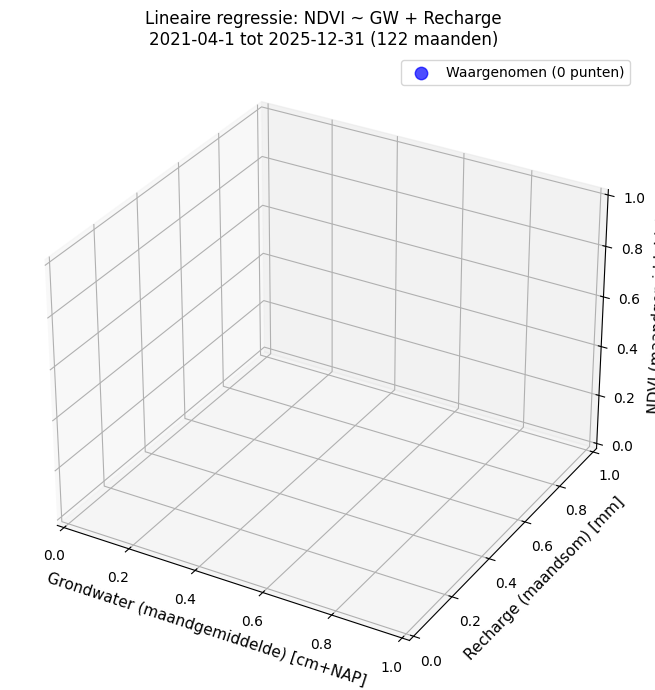

In [16]:
# ================================
# 1) OLS Lineaire regressie NDVI ~ GW + Recharge
# ================================

# Verwijder rijen met NaN of inf in de regressie-variabelen
regression_vars = ["gw_month", "recharge_month", "ndvi_month"]
df_reg = df_month.copy()
df_reg = df_reg.replace([np.inf, -np.inf], np.nan)
df_reg = df_reg.dropna(subset=regression_vars)

# Voeg interpolatiekolommen opnieuw toe indien nodig
for col in ["ndvi_interpolated", "recharge_interpolated", "gw_interpolated"]:
    if col not in df_reg.columns and col in df_month.columns:
        df_reg[col] = df_month[col]
    elif col not in df_reg.columns:
        df_reg[col] = False

X = df_reg[["gw_month", "recharge_month"]]     # Onafhankelijke variabelen
X = sm.add_constant(X)         # Voeg intercept toe
y = df_reg["ndvi_month"]     # Afhankelijke variabele

ols_model = sm.OLS(y, X).fit()

print("\n===============================================")
print("OLS LINEAIRE REGRESSIE RESULTATEN (NDVI ~ GW + Recharge)")
print("===============================================")
print(ols_model.summary())

# ================================
# 3D Scatterplot + regressievlak
# ================================
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')

is_obs = ~(df_reg["ndvi_interpolated"] | df_reg["recharge_interpolated"] | df_reg["gw_interpolated"])

ax.scatter(df_reg.loc[is_obs, "gw_month"], df_reg.loc[is_obs, "recharge_month"], df_reg.loc[is_obs, "ndvi_month"],
           label=f"Waargenomen ({is_obs.sum()} punten)", marker="o", s=80, alpha=0.7, color="blue")

ax.set_xlabel("Grondwater (maandgemiddelde) [cm+NAP]", fontsize=11)
ax.set_ylabel("Recharge (maandsom) [mm]", fontsize=11)
ax.set_zlabel("NDVI (maandgemiddelde)", fontsize=11)
ax.set_title(f"Lineaire regressie: NDVI ~ GW + Recharge\n{NDVI_START_DATE} tot {NDVI_END_DATE} ({len(df_reg)} maanden)", fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


### ARDL(1,1) Summary
```
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             ndvi_month   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     111.6
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           6.70e-26
Time:                        13:44:31   Log-Likelihood:                 158.54
No. Observations:                  56   AIC:                            -305.1
Df Residuals:                      50   BIC:                            -292.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1200      0.090      1.336      0.188      -0.060       0.300
gw_month           0.0057      0.054      0.106      0.916      -0.102       0.113
recharge_month     0.0558      0.052      1.071      0.289      -0.049       0.160
gw_lag1            0.0010      0.050      0.021      0.983      -0.099       0.101
recharge_lag1     -0.2122      0.059     -3.622      0.001      -0.330      -0.095
ndvi_lag1          0.8490      0.044     19.412      0.000       0.761       0.937
==============================================================================
Omnibus:                        1.605   Durbin-Watson:                   1.602
Prob(Omnibus):                  0.448   Jarque-Bera (JB):                1.516
Skew:                          -0.384   Prob(JB):                        0.469
Kurtosis:                       2.756   Cond. No.                         460.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
```

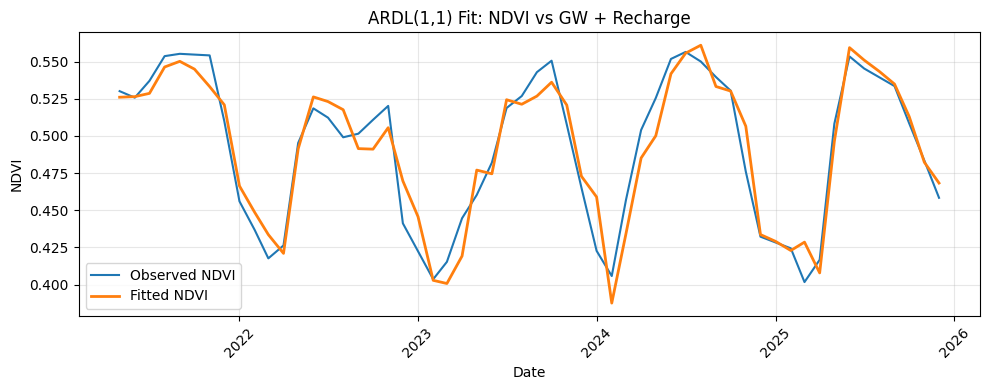

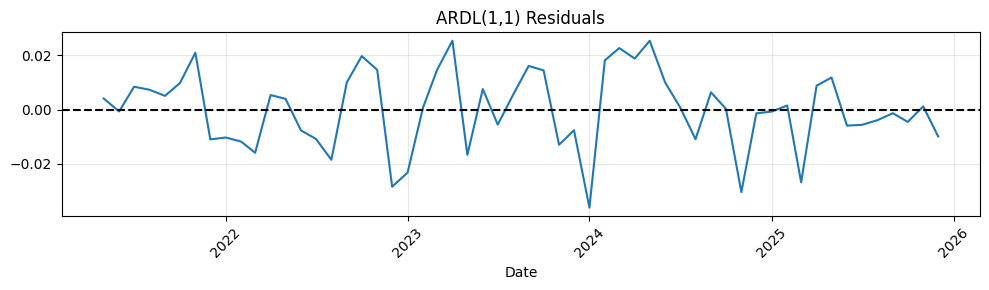

### ARDL(2,2) Summary
```
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             ndvi_month   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     112.5
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           5.36e-28
Time:                        13:44:31   Log-Likelihood:                 172.67
No. Observations:                  56   AIC:                            -327.3
Df Residuals:                      47   BIC:                            -309.1
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1410      0.074      1.907      0.063      -0.008       0.290
gw_month           0.0188      0.044      0.433      0.667      -0.069       0.106
recharge_month     0.0527      0.046      1.155      0.254      -0.039       0.144
gw_lag1           -0.0319      0.060     -0.532      0.597      -0.153       0.089
gw_lag2            0.0188      0.039      0.476      0.637      -0.061       0.098
recharge_lag1     -0.0914      0.075     -1.220      0.229      -0.242       0.059
recharge_lag2     -0.0603      0.055     -1.101      0.277      -0.170       0.050
ndvi_lag1          1.3081      0.101     13.011      0.000       1.106       1.510
ndvi_lag2         -0.5148      0.106     -4.863      0.000      -0.728      -0.302
==============================================================================
Omnibus:                        0.383   Durbin-Watson:                   2.222
Prob(Omnibus):                  0.826   Jarque-Bera (JB):                0.055
Skew:                          -0.051   Prob(JB):                        0.973
Kurtosis:                       3.115   Cond. No.                     1.02e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.02e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
```

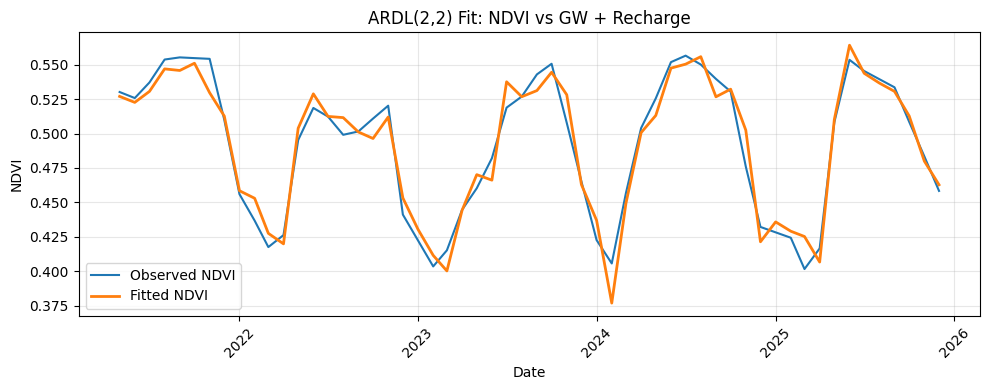

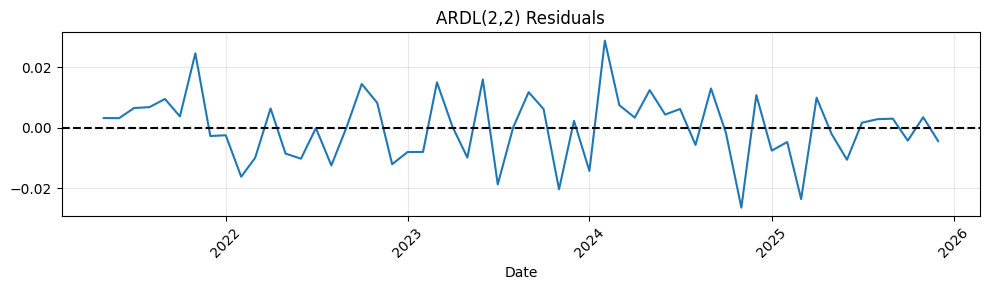

### ARDL(3,3) Summary
```
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             ndvi_month   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     75.32
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           2.08e-24
Time:                        13:44:31   Log-Likelihood:                 169.55
No. Observations:                  55   AIC:                            -315.1
Df Residuals:                      43   BIC:                            -291.0
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1355      0.089      1.528      0.134      -0.043       0.314
gw_month           0.0282      0.051      0.557      0.580      -0.074       0.130
recharge_month     0.0472      0.048      0.990      0.328      -0.049       0.143
gw_lag1           -0.0709      0.088     -0.807      0.424      -0.248       0.106
gw_lag2            0.0869      0.112      0.779      0.440      -0.138       0.312
gw_lag3           -0.0390      0.061     -0.644      0.523      -0.161       0.083
recharge_lag1     -0.0956      0.078     -1.222      0.228      -0.253       0.062
recharge_lag2     -0.0636      0.069     -0.918      0.364      -0.203       0.076
recharge_lag3      0.0017      0.061      0.029      0.977      -0.121       0.125
ndvi_lag1          1.3609      0.149      9.145      0.000       1.061       1.661
ndvi_lag2         -0.6182      0.257     -2.405      0.021      -1.137      -0.100
ndvi_lag3          0.0543      0.149      0.365      0.717      -0.246       0.354
==============================================================================
Omnibus:                        0.238   Durbin-Watson:                   2.220
Prob(Omnibus):                  0.888   Jarque-Bera (JB):                0.006
Skew:                           0.005   Prob(JB):                        0.997
Kurtosis:                       3.048   Cond. No.                     2.49e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.49e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
```

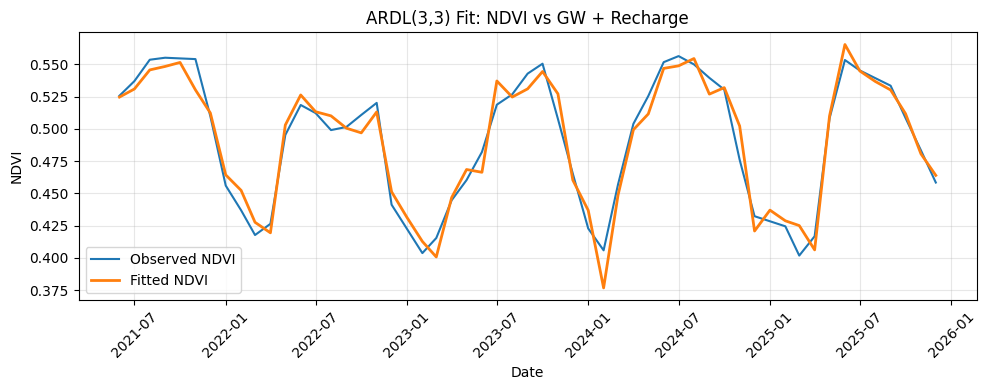

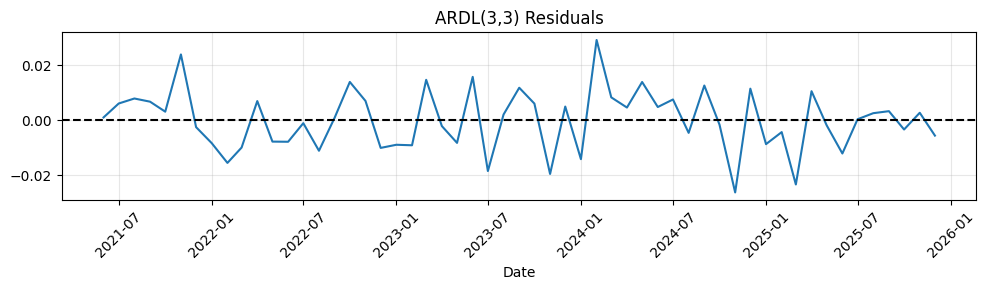

In [17]:
# ================================
# ARDL Models NDVI ~ GW + Recharge
# ================================

results = []
metrics = []

for p in [1, 2, 3]:
    q = p  # ARDL(p,p)

    # Create lagged dataframe
    df_lagged = df_month.copy()

    # NDVI lags
    for i in range(1, p+1):
        df_lagged[f"ndvi_lag{i}"] = df_lagged["ndvi_month"].shift(i)

    # GW lags
    for j in range(1, q+1):
        df_lagged[f"gw_lag{j}"] = df_lagged["gw_month"].shift(j)

    # Recharge lags
    for k in range(1, q+1):
        df_lagged[f"recharge_lag{k}"] = df_lagged["recharge_month"].shift(k)

    # Drop missing rows
    df_lagged = df_lagged.dropna()

    # Build X and y
    lag_cols = ["gw_month", "recharge_month"] + \
               [f"gw_lag{j}" for j in range(1, q+1)] + \
               [f"recharge_lag{k}" for k in range(1, q+1)] + \
               [f"ndvi_lag{i}" for i in range(1, p+1)]
    X = sm.add_constant(df_lagged[lag_cols])
    y = df_lagged["ndvi_month"]

    # Fit model
    model = sm.OLS(y, X).fit()
    results.append((p, q, model))

    # Print summary
    summary_text = model.summary().as_text()
    display(Markdown(f"### ARDL({p},{q}) Summary\n```\n{summary_text}\n```"))

    # Store metrics
    metrics.append({
        "Model": f"ARDL({p},{q})",
        "R²": round(model.rsquared, 3),
        "Adj R²": round(model.rsquared_adj, 3),
        "AIC": round(model.aic, 2),
        "BIC": round(model.bic, 2)
    })

    # Plot fitted vs actual (x-as = datum, alleen de juiste NDVI subset tonen)
    ardl_dates = df_lagged["date"].values if "date" in df_lagged.columns else df_lagged.index
    observed_ndvi = df_lagged["ndvi_month"].values
    plt.figure(figsize=(10, 4))
    plt.plot(ardl_dates, observed_ndvi, label="Observed NDVI")
    plt.plot(ardl_dates, model.fittedvalues, label="Fitted NDVI", linewidth=2)
    plt.title(f"ARDL({p},{q}) Fit: NDVI vs GW + Recharge")
    plt.xlabel("Date")
    plt.ylabel("NDVI")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Plot residuals (x-as = datum)
    plt.figure(figsize=(10, 3))
    plt.plot(ardl_dates, model.resid)
    plt.axhline(0, color="black", linestyle="--")
    plt.title(f"ARDL({p},{q}) Residuals")
    plt.xlabel("Date")
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

                            OLS Regression Results                            
Dep. Variable:             ndvi_month   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     359.9
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           7.02e-59
Time:                        13:44:32   Log-Likelihood:                 328.87
No. Observations:                 121   AIC:                            -649.7
Df Residuals:                     117   BIC:                            -638.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0059      0.059      0.

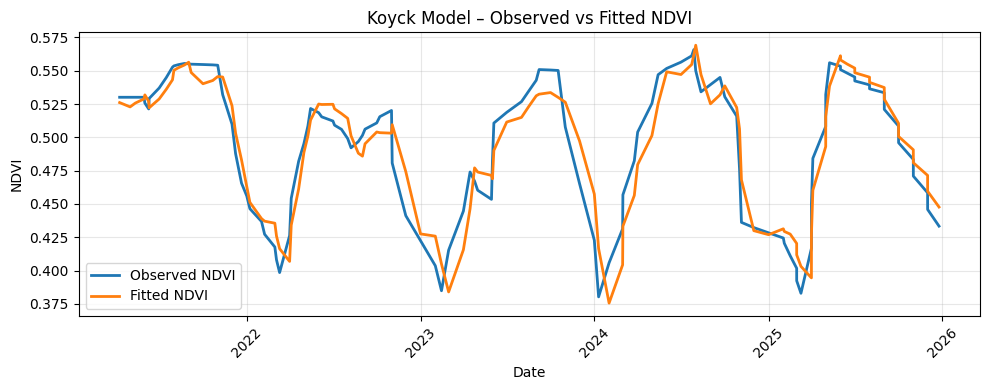

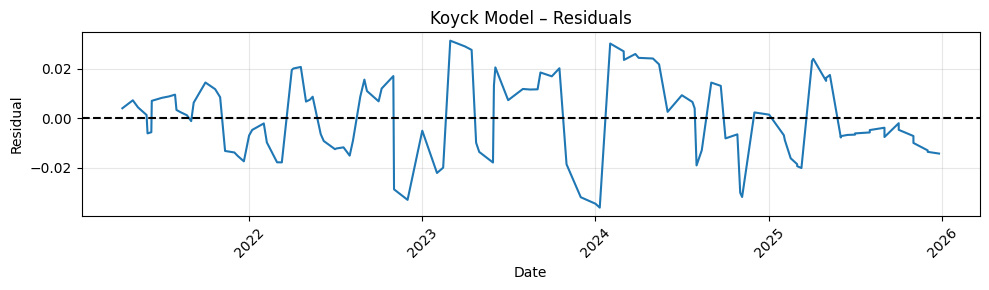

In [18]:
# ================================
# Koyck Transformation Model NDVI ~ GW + Recharge
# ================================

# Zorg dat de grondwaterdata ook NDVI_START_DATE en NDVI_END_DATE gebruikt (is al gedaan in eerdere cellen)
df_koyck = df_month.sort_index().copy()

# Create lag of NDVI: NDVI_{t-1}
df_koyck["ndvi_lag1"] = df_koyck["ndvi_month"].shift(1)

# First row has no lag → drop
df_koyck = df_koyck.dropna(subset=["ndvi_lag1", "recharge_month", "gw_month", "ndvi_month"])

# Define dependent and independent variables
y_k = df_koyck["ndvi_month"]                      # NDVI_t
X_k = df_koyck[["gw_month", "recharge_month", "ndvi_lag1"]]   # GW_t, Recharge_t and NDVI_{t-1}
X_k = sm.add_constant(X_k)                        # intercept

# OLS estimate (Koyck DLM)
koyck_model = sm.OLS(y_k, X_k).fit()
print(koyck_model.summary())

# Plot met x-as = datum, alleen de juiste NDVI subset tonen
koyck_dates = df_koyck["date"].values if "date" in df_koyck.columns else df_koyck.index
observed_ndvi = df_koyck["ndvi_month"].values
plt.figure(figsize=(10,4))
plt.plot(koyck_dates, observed_ndvi, label="Observed NDVI", linewidth=2)
plt.plot(koyck_dates, koyck_model.fittedvalues, label="Fitted NDVI", linewidth=2)
plt.title("Koyck Model – Observed vs Fitted NDVI")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,3))
plt.plot(koyck_dates, koyck_model.resid)
plt.axhline(0, color="black", linestyle="--")
plt.title("Koyck Model – Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# ================================
# Model Comparison Summary
# ================================

summary_rows = []

# ============================================
# 1) LINEAR REGRESSION (OLS model)
# ============================================

n = len(ols_model.model.endog)
k = 1

y_ols = ols_model.model.endog
y_pred_ols = ols_model.fittedvalues
rss = np.sum((y_ols - y_pred_ols)**2)
tss = np.sum((y_ols - np.mean(y_ols))**2)

summary_rows.append({
    "Model": "Linear Regression",
    "R²": ols_model.rsquared,
    "Adj R²": ols_model.rsquared_adj,
    "Prob(F)": ols_model.f_pvalue,
    "AIC": ols_model.aic,
    "BIC": ols_model.bic
})

# ============================================
# 2) ARDL MODELS
# ============================================

for (p, q, model) in results:
    summary_rows.append({
        "Model": f"ARDL({p},{q})",
        "R²": model.rsquared,
        "Adj R²": model.rsquared_adj,
        "Prob(F)": model.f_pvalue,
        "AIC": model.aic,
        "BIC": model.bic
    })

# ============================================
# 3) KOYCK DLM
# ============================================

summary_rows.append({
    "Model": "Koyck Transformation",
    "R²": koyck_model.rsquared,
    "Adj R²": koyck_model.rsquared_adj,
    "Prob(F)": koyck_model.f_pvalue,
    "AIC": koyck_model.aic,
    "BIC": koyck_model.bic
})

# ============================================
# CREATE TABLE
# ============================================

summary_df = pd.DataFrame(summary_rows).round(4)
display(summary_df)

,Model,R²,Adj R²,Prob(F),AIC,BIC
0,Linear Regression,0.1659,0.1519,0.0,-396.1553,-387.7432
1,"ARDL(1,1)",0.9178,0.9096,0.0,-305.0805,-292.9284
2,"ARDL(2,2)",0.9504,0.9419,0.0,-327.3383,-309.1102
3,"ARDL(3,3)",0.9507,0.9380,0.0,-315.1079,-291.0199
4,Koyck Transformation,0.9022,0.8997,0.0,-649.7426,-638.5595


### Koyck Transformation Model Summary

                            OLS Regression Results                            
Dep. Variable:             ndvi_month   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     543.8
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           2.81e-60
Time:                        13:44:32   Log-Likelihood:                 328.81
No. Observations:                 121   AIC:                            -651.6
Df Residuals:                     118   BIC:                            -643.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0253      0.014      1.

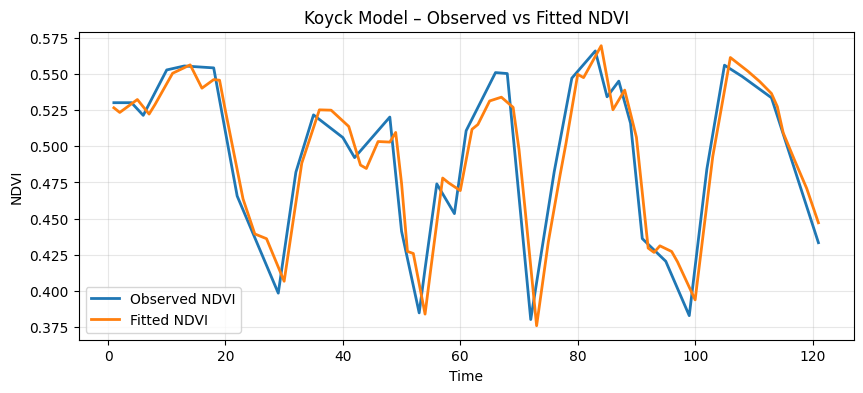

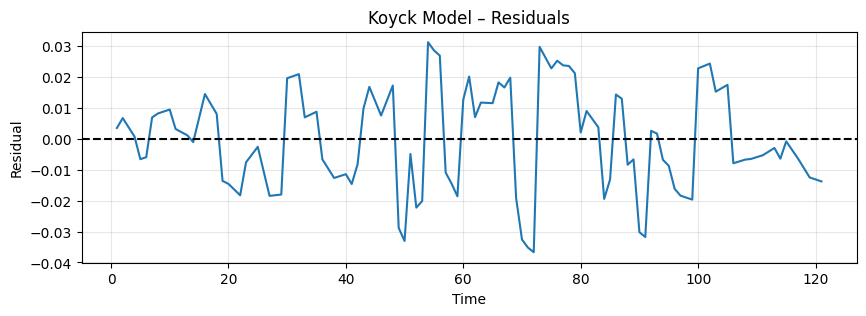

,Model,R²,Adj R²,Prob(F),AIC,BIC
0,Linear Regression,0.1659,0.1519,0.0,-396.1553,-387.7432
1,"ARDL(1,1)",0.9178,0.9096,0.0,-305.0805,-292.9284
2,"ARDL(2,2)",0.9504,0.9419,0.0,-327.3383,-309.1102
3,"ARDL(3,3)",0.9507,0.9380,0.0,-315.1079,-291.0199
4,Koyck Transformation,0.9021,0.9005,0.0,-651.6257,-643.2384


In [20]:
# ================================
# Koyck Transformation Model
# ================================

# Maak een kopie van de maandelijkse data, gesorteerd op tijd
df_koyck = df_month.sort_index().copy()

# Voeg NDVI lag 1 toe (NDVI_{t-1})
df_koyck["ndvi_lag1"] = df_koyck["ndvi_month"].shift(1)

# Drop eerste rij met NaN in lag of in NDVI/Recharge
df_koyck = df_koyck.dropna(subset=["ndvi_lag1", "recharge_month", "ndvi_month"])

# Definieer afhankelijke en onafhankelijke variabelen
y_k = df_koyck["ndvi_month"]                    # NDVI_t
X_k = df_koyck[["recharge_month", "ndvi_lag1"]] # huidige Recharge en NDVI_{t-1}
X_k = sm.add_constant(X_k)                      # voeg intercept toe

# Fit Koyck model (OLS)
koyck_model = sm.OLS(y_k, X_k).fit()
display(Markdown("### Koyck Transformation Model Summary"))
print(koyck_model.summary())

# Plot Observed vs Fitted
plt.figure(figsize=(10, 4))
plt.plot(df_koyck.index, y_k, label="Observed NDVI", linewidth=2)
plt.plot(df_koyck.index, koyck_model.fittedvalues, label="Fitted NDVI", linewidth=2)
plt.title("Koyck Model – Observed vs Fitted NDVI")
plt.xlabel("Time")
plt.ylabel("NDVI")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Plot Residuals
plt.figure(figsize=(10, 3))
plt.plot(df_koyck.index, koyck_model.resid)
plt.axhline(0, color="black", linestyle="--")
plt.title("Koyck Model – Residuals")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.grid(alpha=0.3)
plt.show()

# ================================
# Model Comparison Summary
# ================================

summary_rows = []

# ============================================
# 1) LINEAR REGRESSION (OLS model)
# ============================================

summary_rows.append({
    "Model": "Linear Regression",
    "R²": ols_model.rsquared,
    "Adj R²": ols_model.rsquared_adj,
    "Prob(F)": ols_model.f_pvalue,
    "AIC": ols_model.aic,
    "BIC": ols_model.bic
})

# ============================================
# 2) ARDL MODELS
# ============================================

for (p, q, model) in results:
    summary_rows.append({
        "Model": f"ARDL({p},{q})",
        "R²": model.rsquared,
        "Adj R²": model.rsquared_adj,
        "Prob(F)": model.f_pvalue,
        "AIC": model.aic,
        "BIC": model.bic
    })

# ============================================
# 3) KOYCK DLM
# ============================================

summary_rows.append({
    "Model": "Koyck Transformation",
    "R²": koyck_model.rsquared,
    "Adj R²": koyck_model.rsquared_adj,
    "Prob(F)": koyck_model.f_pvalue,
    "AIC": koyck_model.aic,
    "BIC": koyck_model.bic
})

# ============================================
# CREATE TABLE
# ============================================

summary_df = pd.DataFrame(summary_rows).round(4)
display(summary_df)

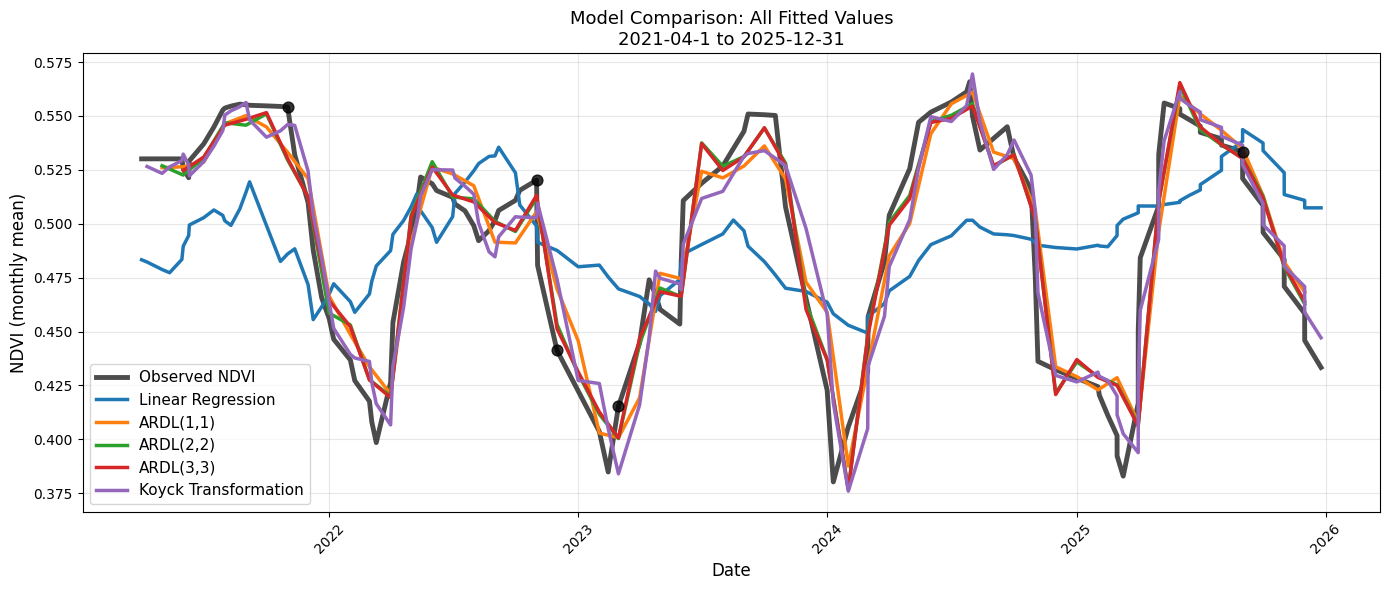

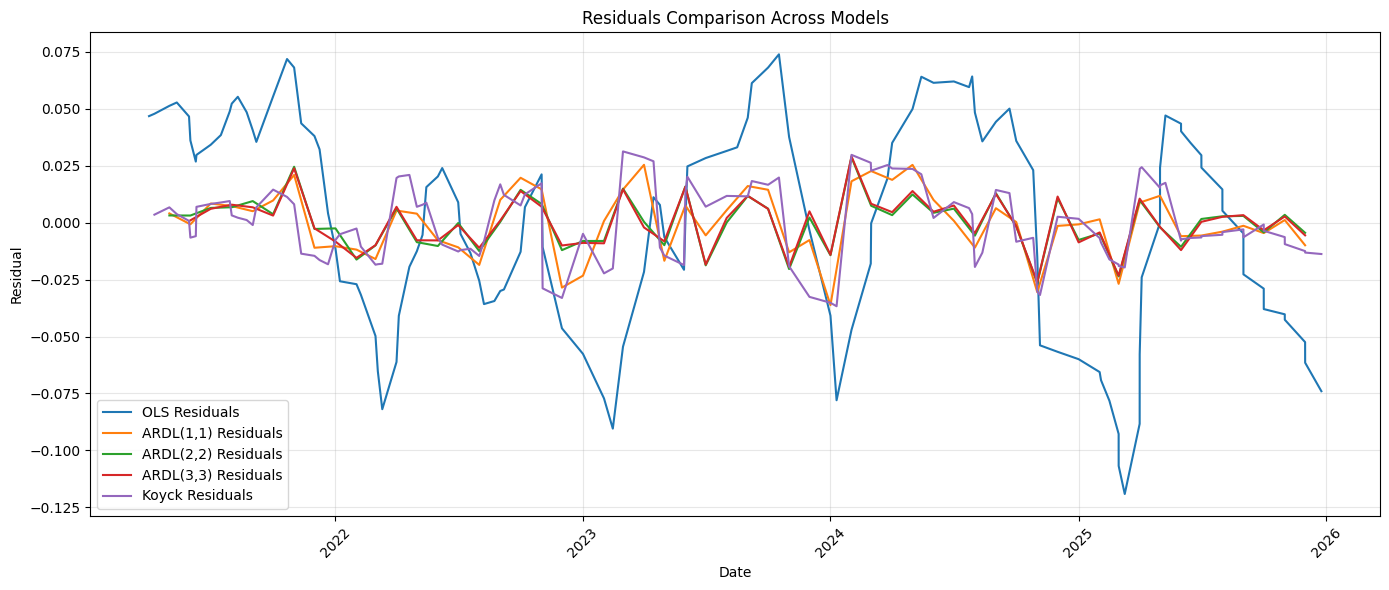

,Model,R²,Adj R²,Prob(F),AIC,BIC
0,Linear Regression,0.1659,0.1519,0.0,-396.1553,-387.7432
1,"ARDL(1,1)",0.9178,0.9096,0.0,-305.0805,-292.9284
2,"ARDL(2,2)",0.9504,0.9419,0.0,-327.3383,-309.1102
3,"ARDL(3,3)",0.9507,0.9380,0.0,-315.1079,-291.0199
4,Koyck Transformation,0.9021,0.9005,0.0,-651.6257,-643.2384


In [21]:
# ================================
# COMBINED MODEL COMPARISON PLOT
# ================================

fig, ax = plt.subplots(figsize=(14, 6))

# Define colors for each model
colors = {
    'ols': '#1f77b4',           # Blue
    'ardl_1_1': '#ff7f0e',      # Orange
    'ardl_2_2': '#2ca02c',      # Green
    'ardl_3_3': '#d62728',      # Red
    'koyck': '#9467bd'          # Purple
}

# Voeg interpolatiekolommen toe indien nodig
for col in ["ndvi_interpolated", "recharge_interpolated"]:
    if col not in df_month.columns:
        df_month[col] = False

# Plot observed NDVI on full timeseries
is_obs_full = ~(df_month["ndvi_interpolated"] | df_month["recharge_interpolated"])
ax.plot(df_month["date"], df_month["ndvi_month"],
        color="black", linewidth=3.5, alpha=0.7, label="Observed NDVI", zorder=3)
ax.scatter(df_month.loc[is_obs_full, "date"], df_month.loc[is_obs_full, "ndvi_month"],
          marker="o", s=60, alpha=0.8, color="black", zorder=10)

# 1) Linear Regression (OLS)
# Get dates corresponding to OLS model observations using label-based indexing
ols_dates = df_month.loc[ols_model.fittedvalues.index, "date"].values
ax.plot(ols_dates, ols_model.fittedvalues.values, 
        linewidth=2.5, color=colors['ols'], label="Linear Regression", zorder=5)

# 2) ARDL Models
for idx, (p, q, model) in enumerate(results):
    model_key = f'ardl_{p}_{q}'
    # Get original indices from the model using label-based indexing
    ardl_indices = model.fittedvalues.index
    ardl_dates = df_month.loc[ardl_indices, "date"].values
    ax.plot(ardl_dates, model.fittedvalues.values, 
           linewidth=2.5, color=colors[model_key], label=f"ARDL({p},{q})", zorder=5)

# 3) Koyck Model
# Use label-based indexing instead of positional
koyck_dates = df_koyck.loc[koyck_model.fittedvalues.index, "date"].values
ax.plot(koyck_dates, koyck_model.fittedvalues.values, 
       linewidth=2.5, color=colors['koyck'], label="Koyck Transformation", zorder=5)

# Format plot
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("NDVI (monthly mean)", fontsize=12)
ax.set_title(f"Model Comparison: All Fitted Values\n{NDVI_START_DATE} to {NDVI_END_DATE}", fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------- RESIDUALS COMPARISON ----------
plt.figure(figsize=(14,6))

# OLS residuals
ols_dates = df_month.loc[ols_model.resid.index, "date"].values
plt.plot(ols_dates, ols_model.resid.values, label="OLS Residuals", color=colors['ols'], linewidth=1.5)

# ARDL residuals
for p, q, model in results:
    key = f'ardl_{p}_{q}'
    res_dates = df_month.loc[model.resid.index, "date"].values
    plt.plot(res_dates, model.resid.values, label=f"ARDL({p},{q}) Residuals", color=colors[key], linewidth=1.5)

# Koyck residuals
koyck_res_dates = df_koyck.loc[koyck_model.resid.index, "date"].values
plt.plot(koyck_res_dates, koyck_model.resid.values, label="Koyck Residuals", color=colors['koyck'], linewidth=1.5)

plt.xlabel("Date")
plt.ylabel("Residual")
plt.title("Residuals Comparison Across Models")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# finally display summary table

display(summary_df)


In [22]:
# ================================
# Controle: zijn alle modellen over dezelfde tijdsperiode uitgevoerd?
# ================================

def print_model_period(label, dates):
    print(f"{label}: {len(dates)} maanden, {dates.min().date()} t/m {dates.max().date()}")

# 1. OLS model
ols_idx = ols_model.fittedvalues.index
ols_dates = df_month.loc[ols_idx, "date"] if hasattr(ols_model, 'fittedvalues') else pd.Series(dtype='datetime64[ns]')
print_model_period("OLS", ols_dates)

# 2. ARDL modellen
for p, q, model in results:
    idx = model.fittedvalues.index
    dates = df_month.loc[idx, "date"] if hasattr(model, 'fittedvalues') else pd.Series(dtype='datetime64[ns]')
    print_model_period(f"ARDL({p},{q})", dates)

# 3. Koyck model
if 'koyck_model' in globals():
    koyck_idx = koyck_model.fittedvalues.index
    koyck_dates = df_koyck.loc[koyck_idx, "date"] if hasattr(koyck_model, 'fittedvalues') else pd.Series(dtype='datetime64[ns]')
    print_model_period("Koyck", koyck_dates)

# 4. Waargenomen NDVI (volledige tijdreeks)
print_model_period("Observed NDVI (volledig)", df_month["date"])

# 5. Toon verschillen in periodes
print("\nVergelijking van datums per model:")
model_dates = {
    "OLS": set(ols_dates),
    **{f"ARDL({p},{q})": set(df_month.loc[model.fittedvalues.index, "date"]) for p, q, model in results},
    "Koyck": set(koyck_dates) if 'koyck_dates' in locals() else set(),
    "Observed": set(df_month["date"]),
}
all_dates = set.union(*model_dates.values())
for name, dates in model_dates.items():
    missing = sorted(all_dates - dates)
    if missing:
        print(f"{name} mist {len(missing)} maanden: {[d.strftime('%Y-%m-%d') for d in missing]}")
    else:
        print(f"{name} bevat alle maanden.")

OLS: 122 maanden, 2021-04-01 t/m 2025-12-25
ARDL(1,1): 56 maanden, 2021-05-01 t/m 2025-12-01
ARDL(2,2): 56 maanden, 2021-05-01 t/m 2025-12-01
ARDL(3,3): 55 maanden, 2021-06-01 t/m 2025-12-01
Koyck: 121 maanden, 2021-04-08 t/m 2025-12-25
Observed NDVI (volledig): 122 maanden, 2021-04-01 t/m 2025-12-25

Vergelijking van datums per model:
OLS bevat alle maanden.
ARDL(1,1) mist 66 maanden: ['2021-04-01', '2021-04-08', '2021-05-11', '2021-05-30', '2021-06-09', '2021-06-09', '2021-07-15', '2021-07-29', '2021-08-09', '2021-08-23', '2021-09-06', '2021-10-21', '2021-11-11', '2021-12-08', '2021-12-21', '2022-01-07', '2022-02-07', '2022-03-04', '2022-03-11', '2022-04-04', '2022-04-20', '2022-05-09', '2022-05-15', '2022-06-07', '2022-07-04', '2022-07-19', '2022-08-08', '2022-08-23', '2022-09-06', '2022-10-07', '2022-11-02', '2023-02-14', '2023-04-15', '2023-04-24', '2023-05-30', '2023-06-04', '2023-08-16', '2023-09-07', '2023-10-17', '2024-01-10', '2024-02-29', '2024-03-25', '2024-05-14', '2024-07